### Задание:
**Задача 1**
Изучите таблицу users_info, содержащую информацию о пользователях. Проведите разведочный анализ данных:

**Общая информация о таблице**
+ Сколько в таблице строк и столбцов?
+ Какие типы данных у каждого столбца?

**Пропущенные значения**
+Сколько пропущенных значений в каждом столбце?
+ Удалите все строки с пропущенными значениями. Какой процент данных был удалён?

**Выбросы по возрасту**
+ Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
+ Удалите выбросы из таблицы.

**Визуализация**
+ Постройте гистограмму (sns.histplot) распределения возрастов пользователей.



**Задача 2** 
Проанализируйте распределение пользователей по полу и городам:
+ Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.

+ Используйте pivot_table, чтобы представить данные:
— города в строках,
— пол в столбцах.
+ Для каждого города рассчитайте долю женщин среди всех пользователей.
+ Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

**Задача 3** Сегментация

Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.

Рассчитайте среднее количество тренировок в месяц для каждого пользователя.

**Подсказка:** для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы. 
+ Разделите пользователей на три группы по уровню активности:

— мало (редко тренируются),

— средне,

— много (тренируются часто).

+ Посчитайте, сколько пользователей входит в каждую из этих групп.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [8]:
users_info.shape # видим 1000 строк и 4 столбца

(1000, 4)

In [9]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [10]:
users_info.isnull().sum() #видим пропущенные строки в столбцах age и gender, их там 8,8 и 8,9%, соответственно.


id_user     0
city        0
age        88
gender     89
dtype: int64

In [12]:
# Пропущенных значений меньше 10%, значит их можно удалить.
df_u = users_info.dropna()
df_u.isnull().sum()

id_user    0
city       0
age        0
gender     0
dtype: int64

In [13]:
#выбросы по возрасту колонки age

q1 = np.percentile(df_u['age'], 25)
q3 = np.percentile(df_u['age'], 75)

iqr = q3 - q1

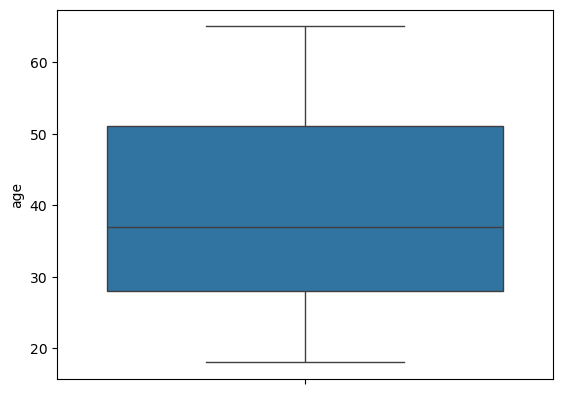

In [25]:
sns.boxplot(df_u['age']); #боксплот не показывает выбросы за рамками усов явно.

In [18]:
df_u # смотрим, сколько строк осталось до удаления выбросов

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female
...,...,...,...,...
993,1993,СПб,36.0,male
994,1994,Казань,46.0,male
995,1995,Москва,43.0,female
997,1997,СПб,58.0,male


In [21]:
# удаляем выбросы и смотрим, сколько строк осталось

df_u_clean = df_u[(df_u['age'] > q1 - 1.5 * iqr) & (df_u['age'] < q3 + 1.5 * iqr)]

df_u_clean #выбросов не обнаружено.

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female
...,...,...,...,...
993,1993,СПб,36.0,male
994,1994,Казань,46.0,male
995,1995,Москва,43.0,female
997,1997,СПб,58.0,male


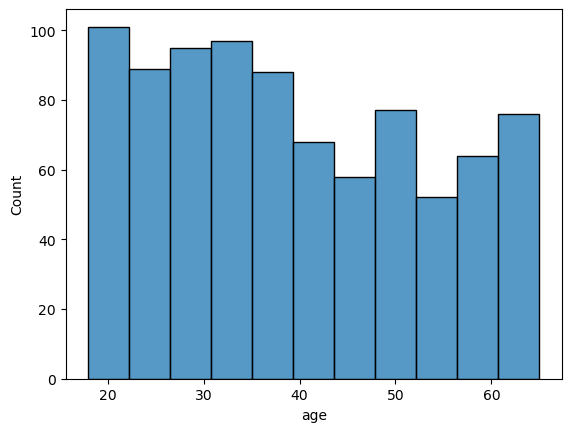

In [24]:
sns.histplot(df_u_clean['age']);

### Задача 2. Доля пользователей-женщин по городам

In [49]:
# Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.

male_users = df_u_clean[df_u_clean['gender'] == 'male'].groupby('city').agg(male = ('gender', 'count'))
female_users = df_u_clean[df_u_clean['gender'] == 'female'].groupby('city').agg(female = ('gender', 'count'))

total_users = male_users.join(female_users)

total_users

,male,female
city,,
Екатеринбург,78,55
Казань,77,53
Москва,105,220
СПб,154,123


In [51]:

# Используйте pivot_table, чтобы представить данные: — города в строках, — пол в столбцах.

pivot_age = df_u_clean.pivot_table(
    index = 'city',     
    columns = 'gender',     
    values = 'id_user',        
    aggfunc = 'count'                
)

pivot_age

gender,female,male
city,,
Екатеринбург,55,78
Казань,53,77
Москва,220,105
СПб,123,154


In [30]:
# Для каждого города рассчитайте долю женщин среди всех пользователей.

pivot_age['share_female'] = (pivot_age['female'] / (pivot_age['female'] + pivot_age['male'])).round(2)

pivot_age

gender,female,male,share_female
city,,,
Екатеринбург,55,78,0.41
Казань,53,77,0.41
Москва,220,105,0.68
СПб,123,154,0.44


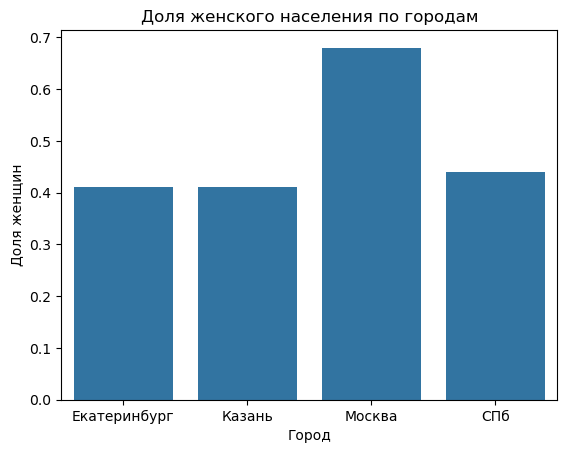

In [40]:
# Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

ax = sns.barplot(pivot_age['share_female'])
ax.set_title('Доля женского населения по городам')
ax.set_xlabel('Город')
ax.set_ylabel('Доля женщин');

# Москва резко выделяется по доли женщин среди других городов, опережая ближайшего конкурента в лице Санкт-Петербурга на 20%.

### Задача 3. Делим пользователей на бины

In [127]:
pay_mon = pd.read_csv('payments_monthly.csv')

In [128]:
pay_mon

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200
...,...,...,...,...,...,...,...,...
5288,1998,2023-03,2,0,1600,0,2,1600
5289,1998,2023-04,6,0,4800,0,6,4800
5290,1998,2023-05,4,0,3200,0,4,3200
5291,1998,2023-06,6,0,4800,0,6,4800


In [ ]:
Рассчитайте среднее количество тренировок в месяц для каждого пользователя.

In [129]:
avg_workouts = pay_mon.groupby('id_user')['cnt_total'].mean()

avg_workouts

id_user
1000     3.666667
1001    11.727273
1002    11.636364
1003     5.166667
1004     2.000000
          ...    
1994     7.000000
1995    11.500000
1996     1.500000
1997     5.000000
1998     4.428571
Name: cnt_total, Length: 969, dtype: float64

In [ ]:
Разделите пользователей на три группы по уровню активности:
— мало (редко тренируются),
— средне,
— много (тренируются часто).


In [130]:
avg_workouts = avg_workouts.reset_index() # преобразуем обратно series в dataframe

avg_workouts.describe() # посмотрим распределение по тренировкам

,id_user,cnt_total
count,969.000000,969.000000
mean,1500.323013,6.342844
std,289.124265,3.538328
min,1000.000000,1.000000
25%,1250.000000,3.500000
50%,1501.000000,5.750000
75%,1752.000000,8.818182
max,1998.000000,18.000000


In [131]:
#бины формируем на основе описательной статистики из avg_workouts.describe(). За низкий берем < q1, за средний  от q1 до q3, за высокий - свыше q3.

bins = [0, 3.5, 8.8, float('inf')]
labels = ['низкий', 'средний', 'высокий']
avg_workouts['bin'] = pd.cut(avg_workouts['cnt_total'], bins = bins, labels = labels, right = True)

avg_workouts

,id_user,cnt_total,bin
0,1000,3.666667,средний
1,1001,11.727273,высокий
2,1002,11.636364,высокий
3,1003,5.166667,средний
4,1004,2.000000,низкий
...,...,...,...
964,1994,7.000000,средний
965,1995,11.500000,высокий
966,1996,1.500000,низкий
967,1997,5.000000,средний


In [132]:
#Посчитайте, сколько пользователей входит в каждую из этих групп.

avg_workouts['bin'].value_counts()


bin
средний    467
низкий     259
высокий    243
Name: count, dtype: int64